# Compare Shared Targets Between Libraries

This notebook compares the number of shared targets between cell pairs across three libraries:
- RETrace v1 (20210920 homopolymer)
- RETrace v1 (20210920)
- RETrace v2 (20240319)

Each cell pair must have >=10x coverage at the same target to count as shared.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## Load Data


In [2]:
# Define VCF files for all three libraries
vcf_files = {
    '\nRETrace v1\n20210920 homopolymer': '/home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_TW1nt12k_500targets_minqual0_minreads10/hipstr/20210920_HCT116_TW1nt12k.vcf',
    '\nRETrace v1\n20210920': '/home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/hipstr/20210920_HCT116_CA2nt24k.vcf',
    '\nRETrace v2\n20240319': '/home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9/hipstr/20240319_3T3L1.vcf'
}

# Minimum coverage threshold
min_coverage = 10

print("Libraries to compare:")
for name, path in vcf_files.items():
    print(f"  {name}: {path}")


Libraries to compare:
  
RETrace v1
20210920 homopolymer: /home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_TW1nt12k_500targets_minqual0_minreads10/hipstr/20210920_HCT116_TW1nt12k.vcf
  
RETrace v1
20210920: /home/tcheng/Projects/RETrace/20210920_NovaSeq_HCT116_1nt12k_2nt24k/results_CA2nt24k_500targets_minqual0_minreads10/hipstr/20210920_HCT116_CA2nt24k.vcf
  
RETrace v2
20240319: /home/tcheng/Projects/RETrace/20240319_AVITI_RETrace2_3T3L1_Tree_Nextflow/results_10000targets_3000cpgs_minqual0.9/hipstr/20240319_3T3L1.vcf


## Parse VCF Files

Function to parse VCF and extract coverage information for each cell at each target.


In [3]:
def parse_vcf(vcf_file):
    """Parse VCF file and return coverage matrix and sample names."""
    targets = []
    samples = []
    coverage_data = []
    
    with open(vcf_file, 'r') as f:
        for line in f:
            if line.startswith('##'):
                continue
            elif line.startswith('#CHROM'):
                # Header line with sample names
                fields = line.strip().split('\t')
                samples = fields[9:]  # Sample names start after FORMAT column
            else:
                # Data line
                fields = line.strip().split('\t')
                target_id = fields[2]  # ID column
                targets.append(target_id)
                
                # Parse FORMAT field to find DP index
                format_fields = fields[8].split(':')
                try:
                    dp_index = format_fields.index('DP')
                except ValueError:
                    dp_index = None
                
                # Extract coverage for each sample
                sample_coverage = []
                for sample_data in fields[9:]:
                    if sample_data == '.' or sample_data.startswith('.:'):
                        sample_coverage.append(0)  # No data
                    else:
                        sample_fields = sample_data.split(':')
                        if dp_index is not None and len(sample_fields) > dp_index:
                            try:
                                dp = int(sample_fields[dp_index])
                            except (ValueError, IndexError):
                                dp = 0
                        else:
                            dp = 0
                        sample_coverage.append(dp)
                
                coverage_data.append(sample_coverage)
    
    # Convert to numpy array
    coverage_matrix = np.array(coverage_data)
    
    return coverage_matrix, samples, targets

# Parse both VCF files
print("Parsing VCF files...\n")
vcf_data = {}
for lib_name, vcf_path in vcf_files.items():
    print(f"Processing {lib_name}...")
    coverage_matrix, samples, targets = parse_vcf(vcf_path)
    vcf_data[lib_name] = {
        'coverage_matrix': coverage_matrix,
        'samples': samples,
        'targets': targets
    }
    print(f"  Samples: {len(samples)}")
    print(f"  Targets: {len(targets)}")
    print()


Parsing VCF files...

Processing 
RETrace v1
20210920 homopolymer...
  Samples: 34
  Targets: 2168

Processing 
RETrace v1
20210920...
  Samples: 49
  Targets: 4913

Processing 
RETrace v2
20240319...
  Samples: 72
  Targets: 49148



## Calculate Shared Targets for All Cell Pairs

For each library, calculate the number of shared targets for each unique cell pair.


In [4]:
def calculate_pairwise_shared_targets(coverage_matrix, samples, min_coverage=10):
    """
    Calculate shared targets for all unique cell pairs.
    Returns list of shared target counts (one per unique pair).
    """
    # Create binary matrix: 1 if coverage >= min_coverage, 0 otherwise
    coverage_binary = (coverage_matrix >= min_coverage).astype(int)
    
    n_samples = len(samples)
    shared_counts = []
    
    # Only calculate for unique pairs (i < j)
    for i in range(n_samples):
        for j in range(i + 1, n_samples):
            # Number of shared targets between cells i and j
            shared = (coverage_binary[:, i] & coverage_binary[:, j]).sum()
            shared_counts.append(shared)
    
    return shared_counts

# Calculate shared targets for both libraries
print("Calculating shared targets for all unique cell pairs...\n")
comparison_data = []

for lib_name, data in vcf_data.items():
    print(f"Processing {lib_name}...")
    shared_counts = calculate_pairwise_shared_targets(
        data['coverage_matrix'], 
        data['samples'], 
        min_coverage
    )
    
    # Add to comparison data
    for count in shared_counts:
        comparison_data.append({
            'Library': lib_name,
            'Shared_Targets': count
        })
    
    print(f"  Unique cell pairs: {len(shared_counts)}")
    print(f"  Mean shared targets: {np.mean(shared_counts):.1f}")
    print(f"  Median shared targets: {np.median(shared_counts):.1f}")
    print()

# Create DataFrame
comparison_df = pd.DataFrame(comparison_data)
print(f"Total data points: {len(comparison_df)}")


Calculating shared targets for all unique cell pairs...

Processing 
RETrace v1
20210920 homopolymer...
  Unique cell pairs: 561
  Mean shared targets: 244.0
  Median shared targets: 237.0

Processing 
RETrace v1
20210920...
  Unique cell pairs: 1176
  Mean shared targets: 258.2
  Median shared targets: 238.0

Processing 
RETrace v2
20240319...
  Unique cell pairs: 2556
  Mean shared targets: 23335.7
  Median shared targets: 23351.0

Total data points: 4293


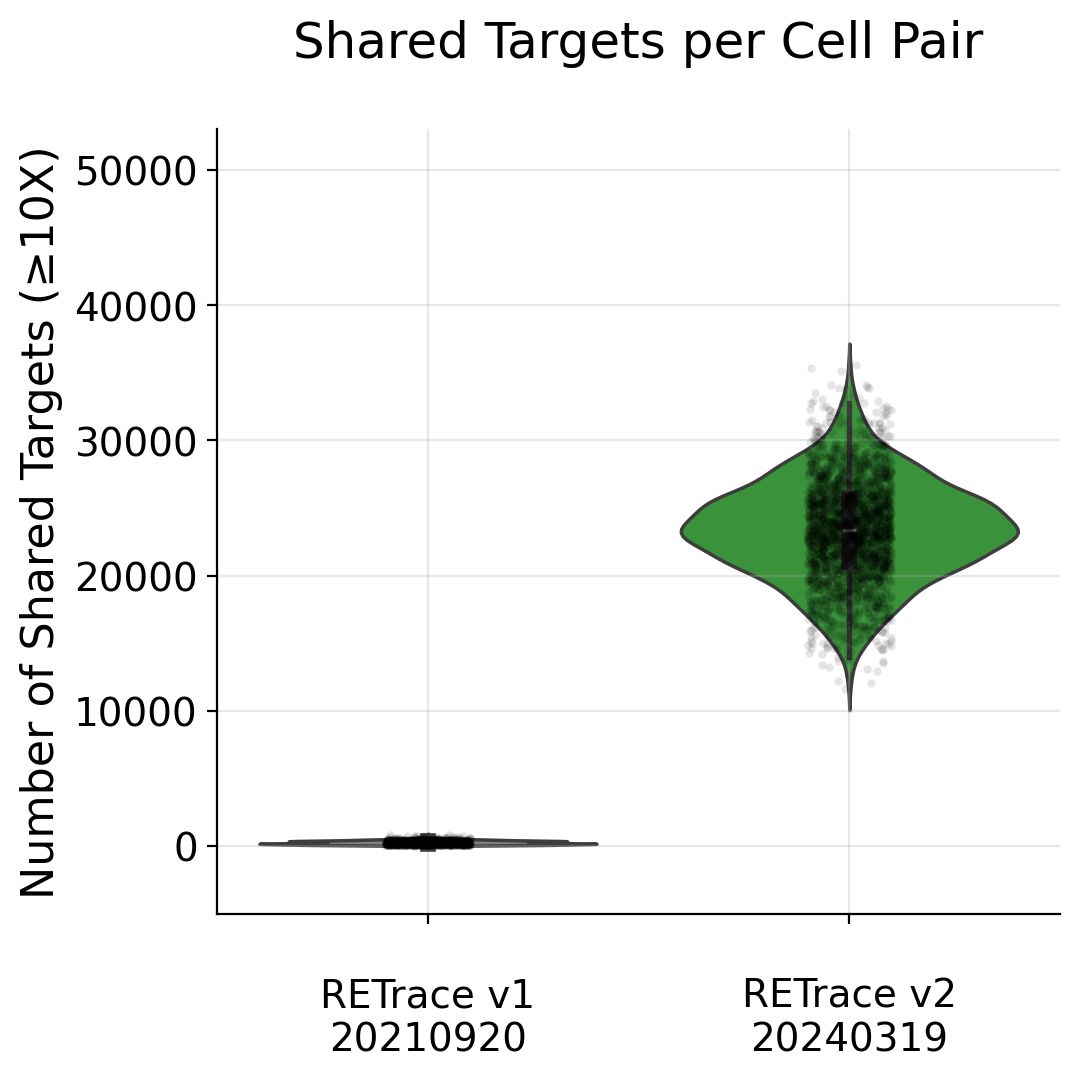


Summary Statistics (2 libraries):
                         count          mean          std      min      25%  \
Library                                                                       
\nRETrace v1\n20210920  1176.0    258.214286   141.614622     28.0    146.0   
\nRETrace v2\n20240319  2556.0  23335.681925  3723.005152  11596.0  20972.0   

                            50%      75%      max  
Library                                            
\nRETrace v1\n20210920    238.0    359.0    843.0  
\nRETrace v2\n20240319  23351.0  25730.0  35598.0  


In [5]:
# Filter data for only two libraries
libraries_to_plot = ['\nRETrace v1\n20210920', '\nRETrace v2\n20240319']
comparison_df_filtered = comparison_df[comparison_df['Library'].isin(libraries_to_plot)]

# Create comparison violin plot (2 libraries)
fig, ax = plt.subplots(figsize=(5.5, 5.5), dpi=200)

# Define colors for the two libraries
palette = {'\nRETrace v1\n20210920': 'tab:gray', '\nRETrace v2\n20240319': 'tab:green'}

# Create violin plot
sns.violinplot(x='Library', y='Shared_Targets', data=comparison_df_filtered, hue='Library', palette=palette, ax=ax)

# Overlay strip plot (each dot is a cell pair)
sns.stripplot(x='Library', y='Shared_Targets', data=comparison_df_filtered, color='black', ax=ax, size=3, alpha=0.1)

# Formatting
ax.set_xlabel("", fontsize=16)
ax.set_title("Shared Targets per Cell Pair\n", fontsize=18)
ax.set_ylabel('Number of Shared Targets (≥10X)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.set_ylim(-5000, 53000)
ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig("SharedTargets_Comparison.pdf")
plt.show()

# Print summary statistics
print("\nSummary Statistics (2 libraries):")
print(comparison_df_filtered.groupby('Library')['Shared_Targets'].describe())


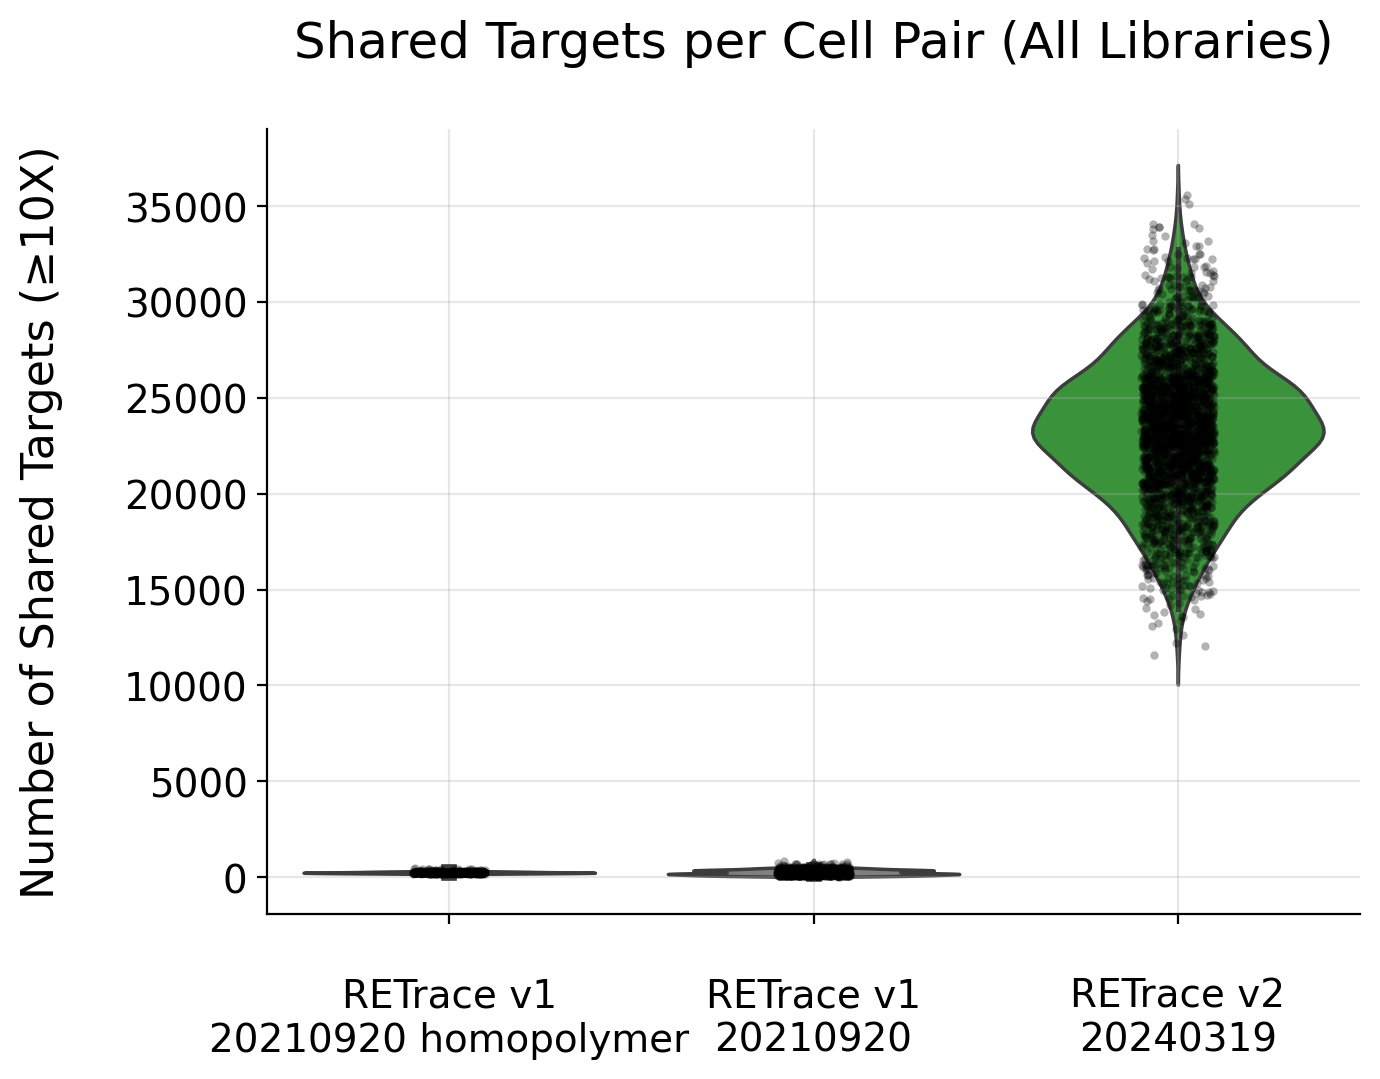


Summary Statistics (All 3 libraries):
                                     count          mean          std  \
Library                                                                 
\nRETrace v1\n20210920              1176.0    258.214286   141.614622   
\nRETrace v1\n20210920 homopolymer   561.0    243.983957    47.185176   
\nRETrace v2\n20240319              2556.0  23335.681925  3723.005152   

                                        min      25%      50%      75%  \
Library                                                                  
\nRETrace v1\n20210920                 28.0    146.0    238.0    359.0   
\nRETrace v1\n20210920 homopolymer    157.0    212.0    237.0    270.0   
\nRETrace v2\n20240319              11596.0  20972.0  23351.0  25730.0   

                                        max  
Library                                      
\nRETrace v1\n20210920                843.0  
\nRETrace v1\n20210920 homopolymer    468.0  
\nRETrace v2\n20240319              3559

In [6]:
# Create comparison violin plot (all 3 libraries)
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=200)

# Define colors for the three libraries
palette = {
    '\nRETrace v1\n20210920 homopolymer': 'tab:blue',
    '\nRETrace v1\n20210920': 'tab:gray',
    '\nRETrace v2\n20240319': 'tab:green'
}

# Create violin plot
sns.violinplot(x='Library', y='Shared_Targets', data=comparison_df, hue='Library', palette=palette, ax=ax)

# Overlay strip plot (each dot is a cell pair)
sns.stripplot(x='Library', y='Shared_Targets', data=comparison_df, color='black', ax=ax, size=3, alpha=0.3)

# Formatting
ax.set_xlabel("", fontsize=16)
ax.set_title("Shared Targets per Cell Pair (All Libraries)\n", fontsize=18)
ax.set_ylabel('Number of Shared Targets (≥10X)\n', fontsize=16)
ax.tick_params(axis='both', labelsize=14)

ax.grid(True, alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
#plt.savefig("Fig1_SharedTargets_Comparison_3libs.pdf")
plt.show()

# Print summary statistics
print("\nSummary Statistics (All 3 libraries):")
print(comparison_df.groupby('Library')['Shared_Targets'].describe())